# Multivariate Regression for Robot Calibration🤖
## Created By: Maureen Ekwebelem


## 🔧 Overview
In this project, I will be using multivariate linear regression to model the behavior of a robot arm — specifically, to predict the amount of electrical current a joint draws based on its motion. This type of model will be useful in estimating power usage and improving how the robot moves and responds over time.

The data comes from TU Dortmund’s TUDOR Project🤖  and can be accessed here:
[TUDOR Project](https://rst.etit.tu-dortmund.de/en/forschung/robotik/leichtbau/details-tudor/),
[MERIt dataset](https://rst.etit.tu-dortmund.de/en/forschung/robotik/leichtbau/details-tudor/#c11560) 
The data  includes motion and sensor readings from a three-link robot. It’s designed to support research on robot dynamics and control systems.

I wanted to see how far a simple method like linear regression could go when applied to robotics data. This notebook walks through the data, builds and evaluates a model, and uses normalized RSS to measure performance—while also highlighting areas for improvement and future exploration.

## 📂🖼️ Loading & Visualizing the Data


In [1]:
# Import Relevant Libraries
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn import linear_model

The full MERIt dataset is available through the [MERIt site](https://rst.etit.tu-dortmund.de/en/forschung/robotik/leichtbau/details-tudor/#c11560). For this project I will be focusing on a **small subset of the dataset** (2/10 experiments, each capturing about 80 seconds of recorded robot motion) .

- Training data: `exp1.csv` → Training data  
- Testing data:  `exp2.csv` → Testing  data

In [2]:
# Defining Column Headers 

names =[
    't',                                  # Time (secs)
    'q1', 'q2', 'q3',                     # Joint angle (rads)
    'dq1', 'dq2', 'dq3',                  # Joint velocity(rads/sec)
    'I1', 'I2', 'I3',                     # Motor current (A)
    'eps21', 'eps22', 'eps31', 'eps32',   # Strain gauge measurements ($\mu$m /m )
    'ddq1', 'ddq2', 'ddq3'                # Joint accelerations (rad/sec^2)
]

# Loading the Training Data 
df = pd.read_csv('/kaggle/input/training-testingdata-robotcalibration/exp1.csv',index_col = 0)

In [3]:
# Examining the first 5 rows of the dataframe, cross checking with CSV file
df.head(5)

,q1,q2,q3,dq1,dq2,dq3,I1,I2,I3,eps21,eps22,eps31,eps32,ddq1,ddq2,ddq3
t,,,,,,,,,,,,,,,,
0.00,-0.000007,2.4958,-1.1345,-7.880000e-21,-4.940656e-321,3.910000e-29,-0.081623,-0.40812,-0.30609,-269.25,-113.20,3.5918,1.57860,-9.900000e-19,-6.210306e-319,4.920000e-27
0.01,-0.000007,2.4958,-1.1345,-2.260000e-21,-4.940656e-321,2.630000e-31,-0.037411,-0.37241,-0.26698,-270.91,-116.05,1.4585,-1.73980,4.250000e-19,-1.766878e-319,-1.380000e-27
0.02,-0.000007,2.4958,-1.1345,-6.470000e-22,-4.940656e-321,1.760000e-33,-0.066319,-0.40302,-0.31459,-269.25,-112.97,3.5918,0.86753,3.230000e-19,-4.990557e-320,-4.120000e-28
0.03,-0.000007,2.4958,-1.1345,-1.850000e-22,-4.940656e-321,1.180000e-35,-0.068020,-0.43703,-0.28398,-269.97,-114.39,1.6956,-0.08059,1.500000e-19,-1.394253e-320,-1.170000e-28
0.04,-0.000007,2.4958,-1.1345,-5.310000e-23,-4.940656e-321,-5.270900e-03,-0.052715,-0.40472,-0.30779,-269.97,-114.15,3.1177,0.86753,5.930000e-20,-3.581976e-321,-3.770800e-01


To better understand how the system behaves during motion, we start by visualizing how the electrical current  or Joint 2 (I2) changes over time; plotting I2 vs. t. 
This also helps in identifying any unusual patterns in the second joint of the robot and detect abnormalities that may need to be addressed during early on during its development.

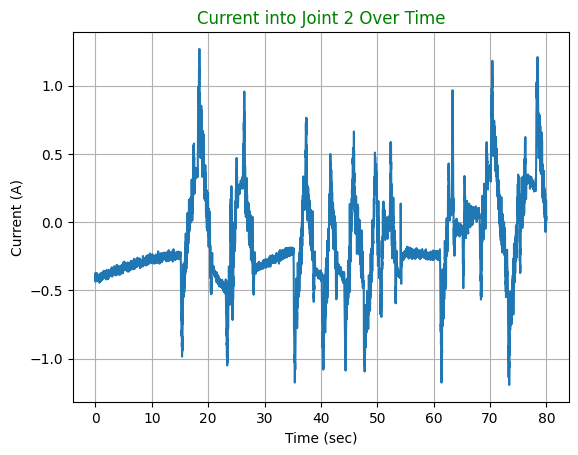

In [4]:
# Plotting Joint 2's Motion
y= df['I2']
t = df.index 

plt.plot(t,y)
plt.title('Current into Joint 2 Over Time', color= 'green')
plt.xlabel('Time (sec)')
plt.ylabel('Current (A)')
plt.grid(True)

The fluctuating signals represent Joint 2's movement; repeated bursts in current from the joint activity. This reveals a clear connection between the joint’s motion and current, which the model is expected to capture.

## 🏷️ Defining the Training Inputs & Labels

Since exp1.csv contains all the data from the 1st experiment, I’ll use it to prepare the training set. Specifically, I’m selecting the current into Joint 2 (I2) as the target variable (ytrain), and choosing features that describe the motion and strain on the joint for the input matrix (Xtrain).

Features included:
>* Joint position (q2), velocity (dq2), and acceleration (ddq2)  
>* Strain gauge readings (eps21, eps22, eps31, eps32)

Since these features describe how the joint moves and how the force is distributed, they should give the model enough information to learn the relationship between motion and current.

In [5]:
# Extract training labels and features from training data
ytrain = df['I2']  # current into Joint 2
Xtrain = df[['q2', 'dq2', 'eps21', 'eps22', 'eps31', 'eps32', 'ddq2']] # features related to joint movement strain

In [6]:
# Create & fit the linear model

regr = linear_model.LinearRegression()
regr.fit(Xtrain, ytrain)

LinearRegression()

In [7]:
# Train the model on the training data
regr.fit(Xtrain, ytrain)

LinearRegression()

Using the trained LR model, I compute the predicted current values (ytrain_pred) based on the training inputs.  I'm ploting both the predicted vs. actual current over time to see how well this model captures the overall trend. This helps to get a visual sense of the model’s fit and spot where it may under or over predict.

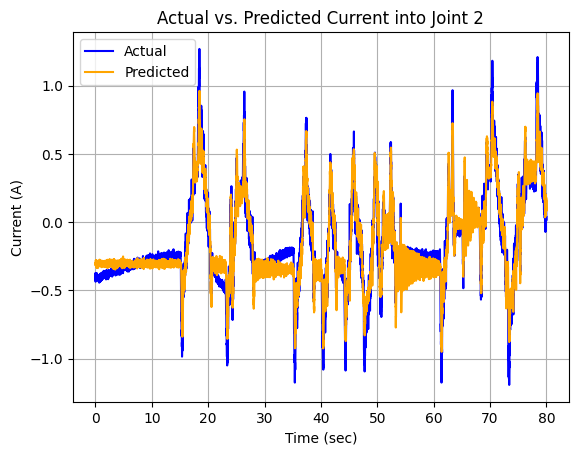

In [8]:
# Predict current using the trained model
ytrain_pred = regr.predict(Xtrain)

# Actual vs Predicted current over time
plt.plot(t, ytrain, label='Actual', color='blue')
plt.plot(t, ytrain_pred, label='Predicted', color='orange')
plt.title('Actual vs. Predicted Current into Joint 2')
plt.xlabel('Time (sec)')
plt.ylabel('Current (A)')
plt.legend()
plt.grid(True)
plt.show()

The current varies with movement, which supports using motion features to predict it.
In order to assess how well the model fits the training data, I’m calculating the normalized residual sum of squares (RSS). The Normalized RSS can be calculated with this formula: RSS / (n s^2_y).

A lower normalized RSS means the model captures more of the variation in the target variable relative to just predicting the mean.

In [9]:
res=ytrain - ytrain_pred
square_res=res**2
RSS_train=np.sum(square_res)
variance =np.var(ytrain, ddof=1)
n=len(ytrain)
RSS_train=np.sum((ytrain-ytrain_pred) **2)

normalized_RSS = RSS_train / (n*variance)
print(f"Normalized RSS for Train Data : {normalized_RSS:.5f}" )

Normalized RSS for Train Data : 0.09582


The low normalized RSS (0.09582) means the model explains most of the variance in the training data; therefore it’s a strong fit, at least on the data it was trained on.

## ⚙️ Testing the LR Model

Now to truly evaluate how well this generalizes, I need to test it on a new separate, independent dataset- the testing data. I’ll load the data from exp2.csv (aka the data from the second experiment). 

In [10]:
# Load the independent test dataset (exp2)
df_exp2=pd.read_csv('/kaggle/input/training-testingdata-robotcalibration/exp2.csv')

# Examining the first 5 rows 
df_exp2.head(5)

,t,q1,q2,q3,dq1,dq2,dq3,I1,I2,I3,eps21,eps22,eps31,eps32,ddq1,ddq2,ddq3
0,0.00,-0.000007,1.9024,0.26063,-0.000364,4.940656e-321,0.012596,-0.096928,-0.15134,-0.017005,-130.83,-41.856,-6.3635,5.13410,-0.045712,6.210306e-319,1.582900
1,0.01,0.000013,1.9024,0.26073,0.000739,4.940656e-321,0.012095,-0.028908,-0.11903,-0.020406,-138.18,-51.100,-14.6590,-5.05820,0.125580,1.766878e-319,0.414660
2,0.02,-0.000007,1.9024,0.26086,-0.000580,4.940656e-321,0.011596,-0.059517,-0.13944,-0.047614,-139.36,-51.812,-14.6590,-5.29520,-0.130080,4.990557e-320,0.082286
3,0.03,0.000013,1.9024,0.26099,0.001409,4.940656e-321,0.013933,-0.079923,-0.15304,-0.023807,-135.57,-48.019,-11.3410,-0.79168,0.213010,1.394253e-320,0.190650
4,0.04,-0.000007,1.9024,0.26110,-0.001273,4.940656e-321,0.010793,-0.025507,-0.12924,-0.006802,-135.81,-49.204,-12.0520,-2.21390,-0.276490,3.581976e-321,-0.170400


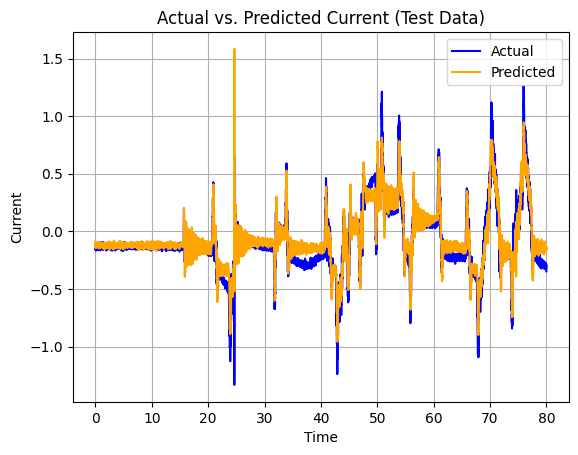

In [11]:
# Define Test Labels and Features from test data (exp2)
ytest=df_exp2['I2']
Xtest=df_exp2[['q2','dq2','eps21', 'eps22', 'eps31', 'eps32','ddq2']]

# Predict using trained model
ytest_pred=regr.predict(Xtest)

# Plot actual vs predicted current for the test data

plt.plot(df_exp2['t'],ytest,label='Actual',color='blue')
plt.plot(df_exp2['t'],ytest_pred,label='Predicted', color='orange')
plt.title('Actual vs. Predicted Current (Test Data)')
plt.xlabel('Time')
plt.ylabel('Current')
plt.grid(True)
plt.legend()
plt.show()

The predictions follow the main pattern, but the model doesn’t respond well to quick spikes or drops. The predictions follow the main pattern, but the model doesn’t respond well to quick spikes or drops.Next, I’ll measure the model’s performance using the normalized RSS.

In [12]:
# Calculating the Testing Data's Normalized RSS 

res_test=ytest-ytest_pred
square_res_test=res_test **2
RSS_test=np.sum(square_res_test)

variance_test=np.var(ytest, ddof=1)
n_test=len(ytest)
normalized_RSS_test=RSS_test /(n_test*variance_test)

print(f"Normalized RSS for Test Data : {normalized_RSS_test:.5f} ")


Normalized RSS for Test Data : 0.12676 


In [13]:
print(f"Normalized RSS for Train Data : {normalized_RSS:.5f}" )
print(f"Normalized RSS for Test Data : {normalized_RSS_test:.5f} ")

Normalized RSS for Train Data : 0.09582
Normalized RSS for Test Data : 0.12676 


The normalized RSS on the test data is slightly higher than the training RSS, which is expected.  
The model works reasonably well but does not capture every detail in the test set. This difference suggests there’s still room for improvement, possibly by using a more flexible model.

## 🧾 Conclusion  

In this project, I trained a linear regression model to predict the current into Joint 2 of a robot using motion and strain data. After preparing the training data from Experiment 1, I fit the model and evaluated its performance.
The model performed well on the training set, with a low normalized RSS of 0.09582, indicating a good fit. 

When tested on independent data from Experiment 2, the model maintained reasonable performance with a normalized RSS of 0.12676. While the predictions followed the general trend of the current signal, the model struggled with sharper transitions and spikes- a limitation that was visible in the plots and reflected in the test error. Overall, this linear model was a strong starting point and helped highlight key relationships between joint motion and current. However, there’s still room for improvement.

Future steps could involve trying more flexible models, such as polynomial regression or regularized methods, to better capture the complex patterns in the data.Other directions might involve incorporating additional sensor features, analyzing residuals more closely, or testing the model across different joints or movement types to evaluate generalizability. Overall, these improvements could help move the model beyond basic trends and toward capturing the full range of joint behavior—bringing us closer to more accurate and reliable robotic calibration.